# ARTI 402 — Deep Learning
## Lab 3 — CNN Architecture: The Four Building Blocks

**Week 3 · Neural Network Architectures**
Convolutional neural networks (CNNs) for image analysis; transfer learning and fine-tuning
pre-trained models.

| | |
|---|---|
| **Marks** | **1 mark** (graded) |
| **Estimated time** | 100–120 minutes |
| **Prerequisites** | Labs 1–2 — shapes, `Layer_Dense`, ReLU, softmax, cross-entropy |
| **Reference** | Ekman, *Learning Deep Learning*, Ch. 7–8 (terminology) |

> **A note on the textbook.** *Neural Networks from Scratch* covers dense networks only — it has
> no chapter on convolution. This lab follows the four-building-block structure from the video,
> and uses Ekman Ch. 7–8 for terminology. We return to NNFS in Lab 5.

---

### How to work through the notebook

* Sections are labelled **Idea** (read and run), **Exercise** (you write code) and **Checkpoint** (a short answer).
* Every exercise cell is marked `# TODO`. Do not delete the cells above it — later cells depend on them.
* Run cells **in order**, top to bottom. If something breaks, restart the kernel and run all.
* The graded **Assessment** is at the very end.

---

### The plan for today

A CNN diagram looks intimidating — blocks, arrows, numbers like 224×224×64. It is much simpler
than it looks. Every CNN image classifier is built from **four blocks**, and you already
understand the fourth one.

| # | Block | What it does | Learnable? |
|---|---|---|---|
| 1 | **Filtering** (convolution) | finds features: edges, curves, textures | **yes** |
| 2 | **Max pooling** | shrinks, keeps the strongest signal | no |
| 3 | **Flatten** | turns a 3-D tensor into a 1-D vector | no |
| 4 | **Fully connected** | classifies — this is Lab 2's `Layer_Dense` | **yes** |

Only blocks 1 and 4 have anything to learn. Blocks 2 and 3 are fixed operations.

Here is the whole thing. Come back to this picture whenever you lose your place — the colours
show which blocks learn and which are fixed.

We work in four stages: **see it → play with it → build it → prove it works.**

### By the end of this lab you should be able to

1. Read any CNN diagram as a sequence of the four blocks.
2. Implement convolution, max pooling and flatten from scratch.
3. Predict the shape of a tensor at every stage of a CNN.
4. Say which blocks have learnable parameters, and count them.
5. Show experimentally why a CNN handles a shifted image when a dense network cannot.

---
## Setup

### Files you need

Put these two files in the **same folder** as this notebook before you start:

| File | What it is |
|---|---|
| `arti402_figures.py` | draws the diagrams in this lab |
| `Zebra_image.jpeg` | the photo used in the architecture diagram |

The notebook still runs without the photo — the diagram just falls back to a grey box. Without
`arti402_figures.py` the import below will fail.

### The code

The next cell carries forward Lab 2 so the notebook stands alone, and adds the dataset. Read it,
run it, move on.


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)

IMG = 12          # our images are 12 x 12 pixels, greyscale


# ---------- carried forward from Lab 2 ----------

def relu(x):
    return np.maximum(0, x)


def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)


def categorical_crossentropy(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return np.mean(-np.log(y_pred[range(len(y_pred)), y_true]))


class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.1 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output


def numerical_gradient(param, loss_fn, h=1e-4):
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        original = param[idx]
        param[idx] = original + h; loss_plus = loss_fn()
        param[idx] = original - h; loss_minus = loss_fn()
        param[idx] = original
        grad[idx] = (loss_plus - loss_minus) / (2 * h)
        it.iternext()
    return grad


def train_head(X, y, epochs=120, learning_rate=0.5, seed=42):
    """Train one dense layer + softmax. The Lab 2 loop, packaged up."""
    np.random.seed(seed)
    head = Layer_Dense(X.shape[1], 3)
    loss_fn = lambda: categorical_crossentropy(softmax(head.forward(X)), y)
    params = [head.weights, head.biases]
    for _ in range(epochs):
        grads = [numerical_gradient(p, loss_fn) for p in params]
        for p, g in zip(params, grads):
            p -= learning_rate * g
    return head


# ---------- the dataset ----------

def make_dataset(n_per_class, pos_lo, pos_hi, seed):
    """12x12 shapes. 0 = vertical bar, 1 = horizontal bar, 2 = diagonal bar."""
    rng = np.random.RandomState(seed)
    X, y, length = [], [], 7
    for kind in range(3):
        for _ in range(n_per_class):
            r = rng.randint(pos_lo, pos_hi + 1)
            c = rng.randint(pos_lo, pos_hi + 1)
            img = np.zeros((IMG, IMG))
            if kind == 0:
                img[r:r + length, c:c + 2] = 1.0
            elif kind == 1:
                img[r:r + 2, c:c + length] = 1.0
            else:
                for i in range(length):
                    if r + i < IMG and c + i + 1 < IMG:
                        img[r + i, c + i:c + i + 2] = 1.0
            X.append(np.clip(img + rng.randn(IMG, IMG) * 0.10, 0, 1))
            y.append(kind)
    return np.array(X), np.array(y, dtype="uint8")


names = ["vertical", "horizontal", "diagonal"]
demo_X, demo_y = make_dataset(3, 1, 2, seed=7)

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("\nSetup OK")

Python : 3.13.5
NumPy  : 2.3.4

Setup OK


In [2]:
# Diagrams for this lab live in arti402_figures.py, in the same folder
# as this notebook. Nothing in the lab depends on how they are drawn.
from arti402_figures import (draw_cnn_architecture, draw_convolution_step,
                             draw_max_pooling, draw_lab_pipeline,
                             draw_param_example)

print("figure helpers loaded")

figure helpers loaded


### The architecture, in one picture

Run the cell below. A real CNN just repeats blocks 1 and 2 a few times before blocks 3 and 4.


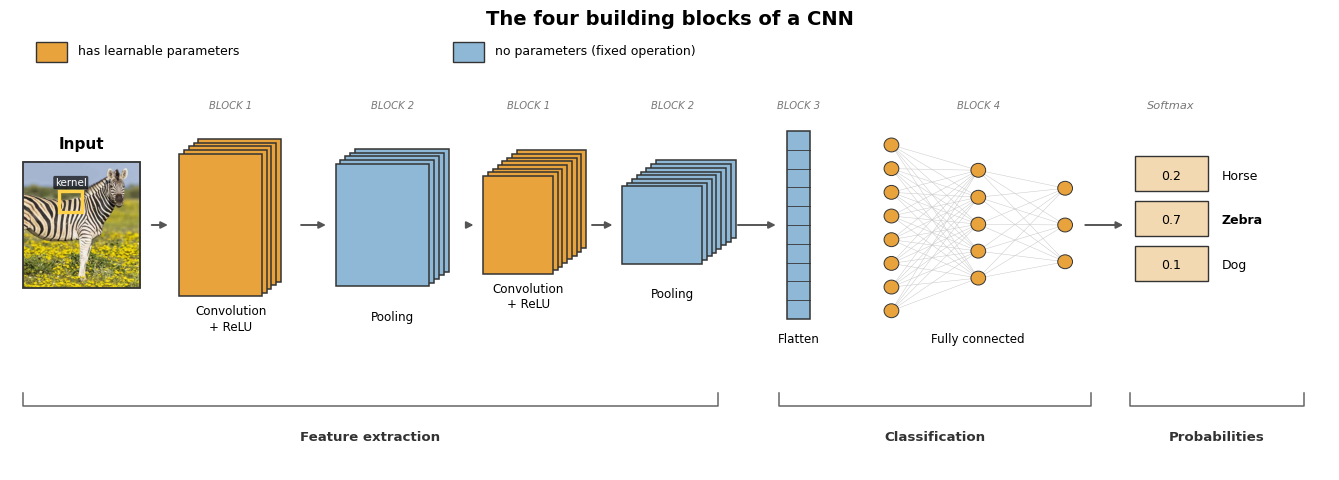

In [3]:
fig = draw_cnn_architecture()
plt.show()

---
---
# Stage 1 · See it work

## Idea 1 — Build an image classifier in five minutes, without writing code

Before understanding how CNNs work, it helps to see one working.

### Do this now

1. Open **https://teachablemachine.withgoogle.com/**
2. Click **Get Started**, then **Image Project**, then **Standard image model**.
3. You get two classes. Give them names — say **"thumbs up"** and **"thumbs down"**.
4. Hold the pose in front of your webcam and press and hold **Webcam → Record** for about
   10 seconds per class. Vary the angle and distance while recording.
5. Press **Train Model** and wait.
6. Show the camera each pose and watch the confidence bars move.

> **Privacy note:** this runs in your browser but is a Google service. Do not upload anything you
> would not want to share. If you would rather not use your webcam, watch a classmate.

### Now ask the right questions

You just trained an image classifier in five minutes with no code. Things to notice:

* It works when you move your hand to a **different part of the frame**. Nothing about position
  was ever specified.
* It needed **very little data** — maybe 100 images per class, where training a network like this
  from scratch would take millions.
* You never told it what a thumb looks like. It found that out.

The rest of this lab answers how. The second point — tiny data — is **transfer learning**, which
we come to at the end. The first point is what the four blocks are for.

### The problem being solved

Here is why you cannot just use a Lab 2 dense network on images.

A 200×200 colour photo is 200 × 200 × 3 = **120,000 numbers**. Connect that to a first hidden
layer of 1,000 neurons and you need 120,000 × 1,000 + 1,000 = **120,001,000 parameters** — for
the *first layer alone*, of a fairly small photo, at about 0.5 GB just to store.

And having paid for all that, the network still cannot handle your hand moving three pixels to
the left. A dense layer learns "this specific pixel matters". Move the object and every pixel
changes, so everything it learned is worthless.


---
---
# Stage 2 · Play with a filter

## Idea 2 — What a filter does, before you code one

### Do this now

Open **https://setosa.io/ev/image-kernels/**

You will see a photograph and a **3×3 grid of numbers**. That grid is a **kernel**, also called a
**filter**. As you hover over the image, the tool shows the small patch of pixels currently under
the kernel and the single output value it produces.

Work through these, and actually look at each result:

1. Pick **blur**. All nine numbers are positive and roughly equal — it averages the neighbourhood.
2. Pick **sobel top**. Top row positive, bottom row negative. Horizontal edges light up; flat
   areas go black.
3. Pick **sobel left**. Now vertical edges light up instead.
4. Pick **outline**. Centre is +8, the eight neighbours are all −1.
5. **Type your own numbers** into the grid. Try all nine zero except the centre.

### The one thing to take away

Nine numbers decide what the filter detects. Change the numbers, change the feature.

And notice what stays constant: **the same nine numbers are used at every position in the image.**
That is **weight sharing**, and it is the single most important idea in this lab. A filter that
detects vertical edges detects them *everywhere*, because it is literally the same filter
everywhere. This is where translation invariance comes from.

### Why `sobel left` finds vertical edges

```
[-1  0  +1]
[-2  0  +2]
[-1  0  +1]
```

On a flat patch, the negative left column cancels the positive right column and the output is
zero. At a vertical edge — dark left, bright right — the positives land on bright pixels and the
negatives on dark ones, so the sum is large. Flat regions vanish, edges light up.

### And now the code

The operation you were just hovering over is exactly this:

```
at each position:
    patch  = the 3x3 pixels under the kernel
    output = sum(patch * kernel)
    slide one pixel, repeat
```

Two nested loops. That is the whole thing. Run the cell below to see one step of it worked out
in full.

> **A note on the name.** What deep learning calls "convolution" is, strictly,
> *cross-correlation* — true convolution flips the kernel first. Since the weights are learned
> anyway, the flip makes no practical difference and every framework skips it.


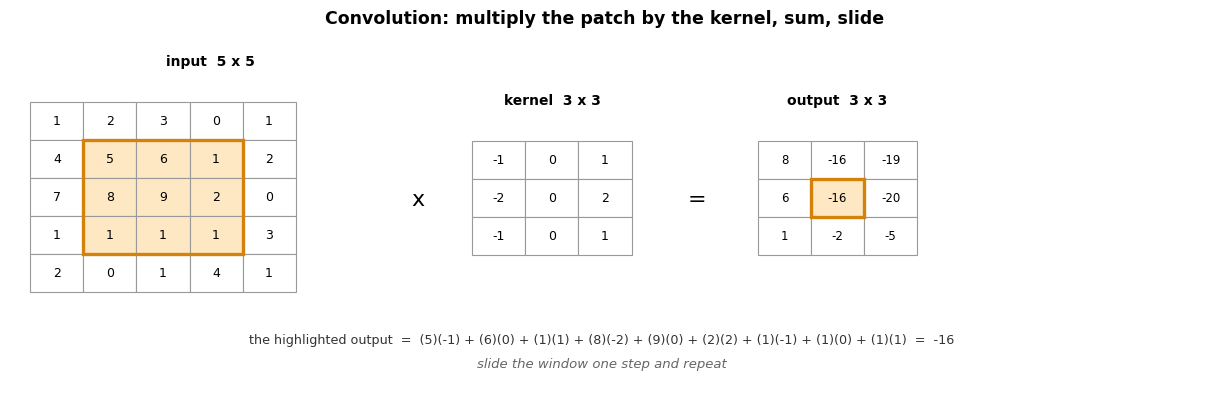

In [4]:
fig = draw_convolution_step()
plt.show()

### Exercise 1 — implement what you just played with

Loop bounds run to `n - f + 1`, not `n`. A 3-wide window on a 5-wide row fits in **3** positions.


In [5]:
def convolve2d(image, kernel, stride=1):
    """Slide `kernel` over `image`. No padding."""
    kh, kw = kernel.shape

    # output size.  (n - f) // stride + 1  in each direction.
    out_h = (image.shape[0] - kh) // stride + 1
    out_w = (image.shape[1] - kw) // stride + 1

    output = np.zeros((out_h, out_w))

    # at each position, multiply the patch by the kernel and sum
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i * stride:i * stride + kh, j * stride:j * stride + kw]
            output[i, j] = np.sum(patch * kernel)

    return output


# --- self-check ---
img = np.array([[1., 2., 3., 0.],
                [4., 5., 6., 1.],
                [7., 8., 9., 2.],
                [1., 1., 1., 1.]])

out = convolve2d(img, np.ones((3, 3)))
assert out.shape == (2, 2), f"4x4 image, 3x3 kernel -> 2x2, got {out.shape}"
assert np.allclose(out, [[45, 36], [42, 34]]), f"wrong values: {out}"
assert convolve2d(np.zeros((12, 12)), np.zeros((3, 3))).shape == (10, 10)
assert convolve2d(np.zeros((12, 12)), np.zeros((3, 3)), stride=2).shape == (5, 5)
print("Exercise 1 passed")

print("\nan all-ones kernel just sums each window:")
print(out)
print("check by hand: 1+2+3+4+5+6+7+8+9 =", 1+2+3+4+5+6+7+8+9)

Exercise 1 passed

an all-ones kernel just sums each window:
[[45. 36.]
 [42. 34.]]
check by hand: 1+2+3+4+5+6+7+8+9 = 45


Now run your own code on the shapes we will classify, and confirm it behaves exactly like
the Setosa demo.

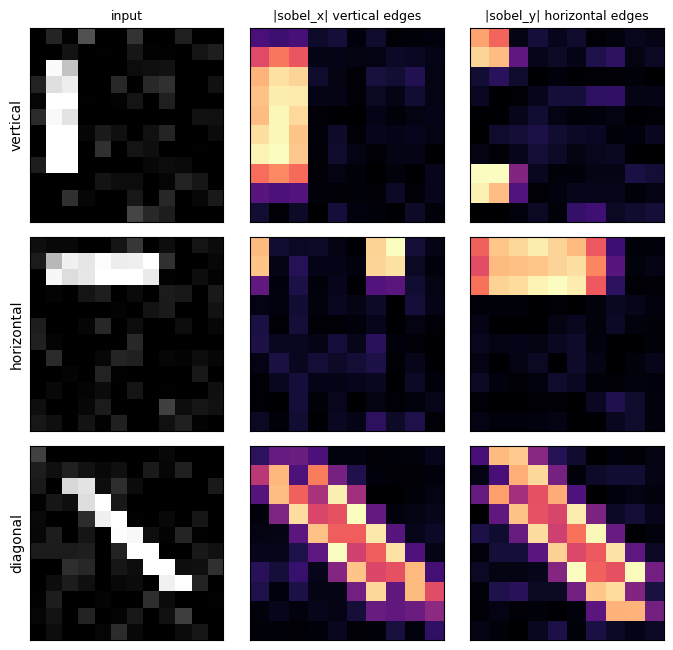

vertical     vertical-edge response  3.97   horizontal  3.00
horizontal   vertical-edge response  2.92   horizontal  3.97
diagonal     vertical-edge response  3.03   horizontal  3.01


In [6]:
sobel_x = np.array([[-1., 0., 1.],
                    [-2., 0., 2.],
                    [-1., 0., 1.]])      # vertical edges

sobel_y = np.array([[-1., -2., -1.],
                    [ 0.,  0.,  0.],
                    [ 1.,  2.,  1.]])    # horizontal edges

samples = [demo_X[demo_y == k][0] for k in range(3)]

fig, axes = plt.subplots(3, 3, figsize=(7, 6.6))
for row, (im, nm) in enumerate(zip(samples, names)):
    axes[row, 0].imshow(im, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(np.abs(convolve2d(im, sobel_x)), cmap="magma")
    axes[row, 2].imshow(np.abs(convolve2d(im, sobel_y)), cmap="magma")
    axes[row, 0].set_ylabel(nm, fontsize=10)
    for c in range(3):
        axes[row, c].set_xticks([]); axes[row, c].set_yticks([])

for c, t in enumerate(["input", "|sobel_x| vertical edges", "|sobel_y| horizontal edges"]):
    axes[0, c].set_title(t, fontsize=9)
plt.tight_layout(); plt.show()

for im, nm in zip(samples, names):
    print(f"{nm:11s}  vertical-edge response {np.abs(convolve2d(im, sobel_x)).max():5.2f}   "
          f"horizontal {np.abs(convolve2d(im, sobel_y)).max():5.2f}")

The vertical bar responds more strongly to `sobel_x`; the horizontal bar reverses it; the
diagonal scores about evenly. The gaps are not huge — a vertical bar has horizontal edges at its
two *ends*, so `sobel_y` does find something. What separates the classes is the **pattern**:
which filter wins, and by how much.

**Two numbers per image already distinguish three classes.** That is feature extraction.


---
---
# Stage 3 · Build the four blocks

## Idea 3 — Block 1: the filtering layer

A real convolutional layer uses **many filters at once**, not one. This is the block with the
most jargon, so take the four settings one at a time.

### Setting 1: number of filters → output depth

Each filter produces its own 2-D output, called a **feature map** or **channel**. Stack them and
you get a 3-D tensor:

```
10 filters on a 32x32 image  ->  output 30 x 30 x 10
                                              ^^
                                    depth = number of filters
```

**The depth of the output always equals the number of filters.** One filter looks for one kind of
thing, so ten filters means ten different features detected in parallel.

### Setting 2: filter size

Almost always small and odd: 3×3 is the modern default; 5×5 and 7×7 appear in older
architectures. A small filter sees a small **receptive field** — the patch of input one output
value depends on — but stacking layers grows it quickly.

### Setting 3: filter depth (the one people forget)

**A filter's depth must match the depth of its input.** On an RGB image the input depth is 3, so
each filter is 3×3×**3**. If the previous layer produced 10 channels, each filter in the next
layer is 3×3×**10**.

So a filter is a small 3-D block, not a flat square. It still produces one flat feature map,
because it sums across the depth.

Our images are greyscale, depth 1, so each filter here is just 3×3.

### Setting 4: stride

How far the filter jumps between positions. Stride 1 moves one pixel at a time. Stride 2 skips
every other position and roughly halves the output — a cheap way to downsample.

$$\text{output size} = \left\lfloor \frac{n - f}{s} \right\rfloor + 1$$

| n | f | s | out |
|---|---|---|---|
| 12 | 3 | 1 | 10 |
| 12 | 3 | 2 | 5 |
| 32 | 3 | 1 | 30 |

*(A fifth setting, **padding**, adds a border of zeros so the output does not shrink. With
`p = 1` and a 3×3 kernel, 12×12 stays 12×12. You will meet it in the frameworks in Labs 7–8.)*

### Learnable?

**Yes.** The numbers inside every filter are weights, updated by backpropagation exactly like
Lab 2. Plus one bias per filter.

```
parameters = f * f * depth_in * n_filters  +  n_filters
```

Notice what is **absent**: the image size. A filter costs the same on a thumbnail or a
4000×3000 photo. That is weight sharing paying for itself.

### ReLU comes right after

A filter's response can be negative — `sobel_x` gives a large negative value at an edge running
the other way. ReLU zeros the negatives and leaves positives alone, so each filter answers one
specific question. To catch both edge directions you use two filters, one the negative of the
other. That is exactly what we do below.


### Exercise 2 — the filtering layer

Apply a **list** of filters and stack the results into a 3-D tensor. Use
`np.stack(list_of_2d_arrays, axis=-1)` to make depth the last dimension.


In [7]:
def conv_layer(image, filters, stride=1):
    """Apply every filter. Returns (height, width, n_filters)."""
    # one feature map per filter, stacked so depth is the LAST axis
    feature_maps = [convolve2d(image, f, stride) for f in filters]
    return np.stack(feature_maps, axis=-1)


def relu_layer(tensor):
    # ReLU, elementwise
    return np.maximum(0, tensor)


# --- self-check ---
bank4 = [sobel_x, -sobel_x, sobel_y, -sobel_y]

t = conv_layer(demo_X[0], bank4)
assert t.shape == (10, 10, 4), \
    f"12x12 with 4 filters of 3x3 -> (10, 10, 4), got {t.shape}"

t2 = conv_layer(demo_X[0], bank4, stride=2)
assert t2.shape == (5, 5, 4), f"stride 2 halves the spatial size, got {t2.shape}"

t3 = conv_layer(demo_X[0], [sobel_x])
assert t3.shape == (10, 10, 1), "one filter -> depth 1"

a = relu_layer(t)
assert a.shape == t.shape and np.all(a >= 0), "ReLU keeps the shape, removes negatives"
print("Exercise 2 passed")

print(f"\ninput           {demo_X[0].shape}")
print(f"conv 4 filters  {t.shape}   <- depth 4 because there are 4 filters")
print(f"conv stride 2   {t2.shape}")
print(f"after relu      {a.shape}   (shape unchanged, {np.sum(t < 0)} negatives zeroed)")

Exercise 2 passed

input           (12, 12)
conv 4 filters  (10, 10, 4)   <- depth 4 because there are 4 filters
conv stride 2   (5, 5, 4)
after relu      (10, 10, 4)   (shape unchanged, 197 negatives zeroed)


---
## Idea 4 — Block 2: max pooling

After filtering you have feature maps recording how strongly each filter fired at every location.
Usually that is more detail than you need. Whether a vertical edge appeared at (4, 7) or (4, 8)
rarely matters — what matters is that one appeared *around there*.

**Max pooling** divides each feature map into small tiles and keeps only the largest value.
Run the cell below.

Each channel is pooled **independently**, so depth is unchanged: `(10, 10, 4)` pooled by 2
becomes `(5, 5, 4)`.

### Three advantages

1. **Keeps the dominant feature, drops the noise.** The strongest response in a region survives;
   weak responses do not.
2. **Cuts computation.** 2×2 pooling removes 75% of the numbers, so every later layer is cheaper.
3. **Tolerates small shifts.** Move the input a pixel and the maximum within a tile usually does
   not change — so the output does not change.

> **Be precise about point 3.** Pooling buys tolerance to **small translations**. It does *not*
> make a network rotation-invariant — rotate an image 45° and a max-pooled CNN will happily fail.
> You will sometimes hear "shifts and rotations" claimed together; only the first is right.

### How much to pool

The tile size controls how much position information you discard:

* **2×2** — keeps most of the spatial layout, tolerates roughly a one-pixel shift
* **large tiles** — keeps less layout, tolerates bigger shifts
* **global** (one tile covering the whole map) — keeps no layout at all. The answer becomes purely
  *"does this feature appear anywhere in the image?"*

Whether that is brilliant or catastrophic depends on your problem. You will measure it in the
Assessment.

### Learnable?

**No.** Nothing to train. A fixed operation with zero parameters.


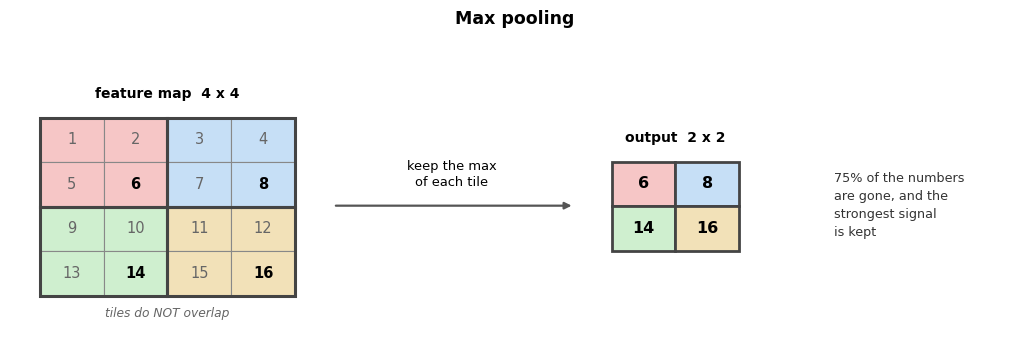

In [8]:
fig = draw_max_pooling()
plt.show()

### Exercise 3 — max pooling

Tiles do **not** overlap, unlike convolution windows. Tile `(i, j)` covers rows `i*size` to
`(i+1)*size`.


In [9]:
def max_pool2d(feature_map, size):
    """Non-overlapping max pooling on one 2-D feature map."""
    # how many whole tiles fit? Use // .
    out_h = feature_map.shape[0] // size
    out_w = feature_map.shape[1] // size

    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            # the maximum of this tile
            tile = feature_map[i * size:(i + 1) * size, j * size:(j + 1) * size]
            output[i, j] = np.max(tile)
    return output


def maxpool_layer(tensor, size):
    """Pool every channel of a 3-D tensor independently."""
    # pool tensor[:, :, c] for each channel c, stack depth-last
    return np.stack([max_pool2d(tensor[:, :, c], size) for c in range(tensor.shape[2])], axis=-1)


# --- self-check ---
fmap = np.arange(1, 17, dtype=float).reshape(4, 4)
assert np.allclose(max_pool2d(fmap, 2), [[6, 8], [14, 16]]), "wrong tile maxima"
assert max_pool2d(fmap, 4).shape == (1, 1) and max_pool2d(fmap, 4)[0, 0] == 16

p = maxpool_layer(a, 2)
assert p.shape == (5, 5, 4), f"(10,10,4) pooled by 2 -> (5,5,4), got {p.shape}"
g = maxpool_layer(a, 10)
assert g.shape == (1, 1, 4), f"global pooling -> (1,1,4), got {g.shape}"
print("Exercise 3 passed")

print("\nfeature map:"); print(fmap)
print("\npooled 2x2:"); print(max_pool2d(fmap, 2))
print(f"\ntensor (10,10,4) -> pool 2  -> {p.shape}   depth is unchanged")
print(f"tensor (10,10,4) -> pool 10 -> {g.shape}   global")

Exercise 3 passed

feature map:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

pooled 2x2:
[[ 6.  8.]
 [14. 16.]]

tensor (10,10,4) -> pool 2  -> (5, 5, 4)   depth is unchanged
tensor (10,10,4) -> pool 10 -> (1, 1, 4)   global


---
## Idea 5 — Blocks 3 and 4: flatten, then classify

### Block 3: flatten

The bridge. Convolution and pooling work in 3-D; a dense layer takes a flat vector. Flatten
unrolls the tensor:

```
(2, 2, 4)  ->  16 numbers in a row
(1, 1, 4)  ->   4 numbers in a row
```

No arithmetic, just a change of view. **Learnable: no. Parameters: zero.**

### Block 4: fully connected

This is `Layer_Dense` from Lab 2 — unchanged. It takes the flat vector and maps it to one neuron
per class, then **softmax** turns those scores into probabilities that sum to 1.

**Learnable: yes.** `n_in * n_out + n_out`, same formula as Lab 1.

### The whole architecture

This is the exact pipeline you are building, with the real shapes. Note that block 1 here is
**frozen** — we use fixed Sobel filters rather than learned ones, for reasons explained in the
Assessment — so only block 4's 15 parameters are actually trained.

**Only blocks 1 and 4 learn anything.** Everything else is fixed plumbing. When you read a CNN
diagram from now on, that is the first thing to look for.


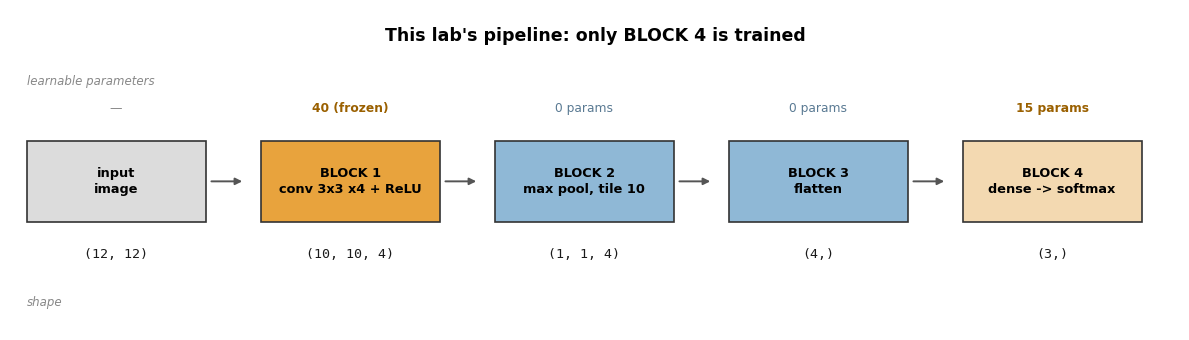

In [10]:
fig = draw_lab_pipeline()
plt.show()

### Exercise 4 — flatten, and trace the shape journey

In [11]:
def flatten_layer(tensor):
    """3-D tensor -> 1-D vector."""
    # one line. np.ravel flattens an array.
    return np.ravel(tensor)


# --- self-check ---
assert flatten_layer(np.zeros((2, 2, 4))).shape == (16,)
assert flatten_layer(np.zeros((1, 1, 4))).shape == (4,)
assert flatten_layer(np.zeros((5, 5, 4))).shape == (100,)
print("Exercise 4 passed")

# The full journey, one image through all four blocks.
img = demo_X[0]
print(f"\n{'stage':<34}{'shape':>16}")
print("-" * 50)
print(f"{'input image':<34}{str(img.shape):>16}")

t = conv_layer(img, bank4);   print(f"{'BLOCK 1  conv, 4 filters':<34}{str(t.shape):>16}")
t = relu_layer(t);            print(f"{'         relu':<34}{str(t.shape):>16}")
t = maxpool_layer(t, 10);     print(f"{'BLOCK 2  max pool, tile 10':<34}{str(t.shape):>16}")
v = flatten_layer(t);         print(f"{'BLOCK 3  flatten':<34}{str(v.shape):>16}")
print(f"{'BLOCK 4  dense -> softmax':<34}{'(3,)':>16}")

print(f"\n144 pixels became {v.shape[0]} numbers, and those {v.shape[0]} are enough.")

Exercise 4 passed

stage                                        shape
--------------------------------------------------
input image                               (12, 12)
BLOCK 1  conv, 4 filters               (10, 10, 4)
         relu                          (10, 10, 4)
BLOCK 2  max pool, tile 10               (1, 1, 4)
BLOCK 3  flatten                              (4,)
BLOCK 4  dense -> softmax                     (3,)

144 pixels became 4 numbers, and those 4 are enough.


### Exercise 5 — count the learnable parameters

Only two of the four blocks have any. Run the cell below to see the architecture, then count.

Remember: each filter's **depth matches its input's depth**. The first conv sees depth 3 (RGB);
the second sees depth 10 (the first layer's 10 feature maps).


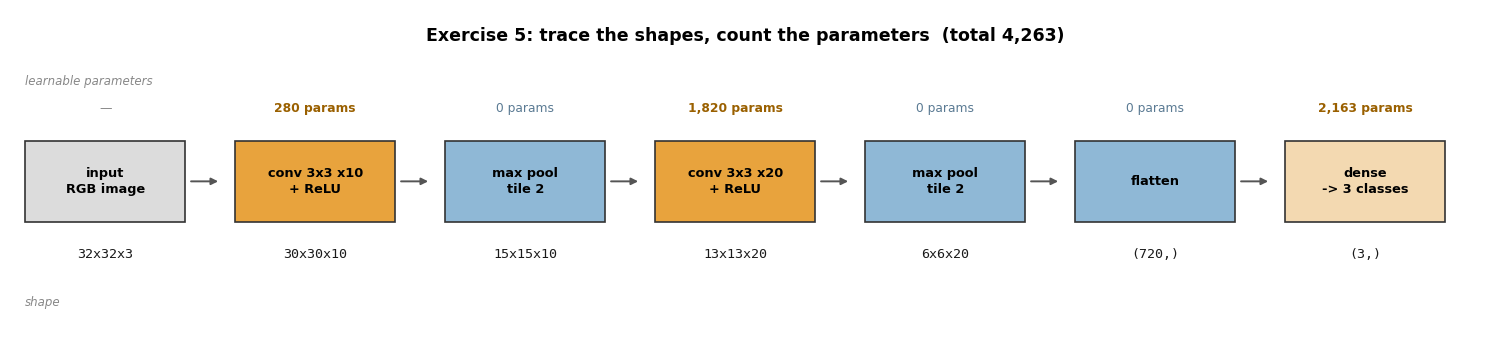

In [12]:
fig = draw_param_example()
plt.show()

In [13]:
def conv_params(f, depth_in, n_filters):
    # f*f*depth_in weights per filter, times n_filters, plus one bias per filter
    return f * f * depth_in * n_filters + n_filters


def dense_params(n_in, n_out):
    # same formula as Lab 1
    return n_in * n_out + n_out


# --- self-check ---
assert conv_params(3, 3, 10) == 280,    "3*3*3*10 + 10 = 280"
assert conv_params(3, 10, 20) == 1820,  "3*3*10*20 + 20 = 1820"
assert conv_params(3, 3, 32) == 896
assert dense_params(720, 3) == 2163
print("Exercise 5 passed")

# parameter count for each block above. Use 0 where there are none.
p_conv1   = conv_params(3, 3, 10)
p_pool1   = 0
p_conv2   = conv_params(3, 10, 20)
p_pool2   = 0
p_flatten = 0
p_dense   = dense_params(720, 3)

rows = [("conv 3x3 x10  (depth 3)",  "30x30x10", p_conv1),
        ("max pool 2",               "15x15x10", p_pool1),
        ("conv 3x3 x20  (depth 10)", "13x13x20", p_conv2),
        ("max pool 2",               "6x6x20",   p_pool2),
        ("flatten",                  "720",      p_flatten),
        ("dense -> 3",               "3",        p_dense)]

print(f"\n{'block':<28}{'output':>12}{'parameters':>13}")
print("-" * 53)
for nm, shp, pp in rows:
    print(f"{nm:<28}{shp:>12}{pp:>13,}")
print("-" * 53)
total = sum(r[2] for r in rows)
print(f"{'TOTAL':<28}{'':>12}{total:>13,}")

assert total == 4263, f"expected 4263, got {total}"
print("\nExercise 5 complete")

print(f"\nFor comparison, ONE dense layer on a 200x200 RGB image with 1000 neurons:")
print(f"  {dense_params(200*200*3, 1000):,} parameters")

Exercise 5 passed

block                             output   parameters
-----------------------------------------------------
conv 3x3 x10  (depth 3)         30x30x10          280
max pool 2                      15x15x10            0
conv 3x3 x20  (depth 10)        13x13x20        1,820
max pool 2                        6x6x20            0
flatten                              720            0
dense -> 3                             3        2,163
-----------------------------------------------------
TOTAL                                           4,263

Exercise 5 complete

For comparison, ONE dense layer on a 200x200 RGB image with 1000 neurons:
  120,001,000 parameters


### Checkpoint 1

1. A convolutional layer has 16 filters. What is the depth of its output tensor?
2. Which of the four blocks have learnable parameters, and which do not?
3. A layer takes an input of depth 10 and uses 3×3 filters. What is the shape of **one** filter?


> **Your answers:**
>
> 1. The output tensor's depth equals the number of filters, so it would be 16 — one feature map per filter.
> 2. **Filtering** (Block 1) and **fully connected** (Block 4) have learnable parameters (weights and biases updated by backpropagation). **Max pooling** (Block 2) and **flatten** (Block 3) are fixed operations with zero learnable parameters.
> 3. A filter's depth must match the depth of its input, so one filter would have shape 3 x 3 x 10.

---
## Idea 6 — See a real one

You now have all four blocks. Time to look at a real trained network with them in mind.

### Do this now

Open **https://poloclub.github.io/cnn-explainer/**

This is a real CNN (a small VGG) trained on ten classes, running live in your browser. It was
built at Georgia Tech specifically for people learning CNNs for the first time.

Work through this list:

1. **Find the four blocks.** Read the layer names along the top: `conv`, `relu`, `max_pool`, then
   more of the same, ending in `output`. Everything you built is there.
2. **Hover over any neuron in the first conv layer.** Watch the kernel slide over the input and
   the output value appear. That is your `convolve2d`, animated.
3. **Click a conv neuron** to open the interactive formula, and look at the actual **kernel
   values**. Many look like edge detectors — dark on one side, bright on the other. **Nobody
   designed these. The network learned them from data**, and it rediscovered the same kind of
   filter you were dragging around on Setosa.
4. **Compare layer 1 with the later layers.** Early feature maps show simple edges. Later ones
   respond to more complex, harder-to-name patterns. This is the hierarchy in Ekman's Figure 7-7:
   edges → textures → parts → objects.
5. **Click the `max_pool` layer** and confirm the spatial size shrinks while the depth stays put.
6. **Click `flatten` at the end** and watch the 3-D tensor unroll into a vector, then into softmax
   probabilities.

### The one thing to notice

The filters in a trained network **look like the ones you played with on Setosa**. We hand-wrote
Sobel filters today because we have not yet built backpropagation through a convolutional layer.
A real network starts from random numbers and discovers edge detectors on its own — because they
genuinely are the right thing to look for.


---
---
# Stage 4 · Prove it works

# Assessment

**Marks: 1**

The question: **does all this machinery actually buy anything?**

To make it a fair test, training and test sets differ in one specific way. Training shapes sit
near the **top-left**. Test shapes sit further **down and to the right** — positions never seen
during training. A model that memorised pixel positions will fail. A model with real translation
invariance will not.

### A note on what we are doing

We cannot download pretrained ImageNet weights without a framework (Labs 7–8). So our filtering
layer is **frozen** — four hand-designed edge filters instead of learned ones — and we train only
the fully connected head.

That is exactly the **transfer learning** pattern, and it is how most real image projects are
built: take a network trained on millions of images, **freeze** its convolutional blocks, replace
the final dense layer with your own, and train only that. Ekman's reason for freezing: the
pretrained filters are the product of an expensive training run, while your new head starts
random, and those large early gradients would wreck the filters before the head learned anything.
**Fine-tuning** is the optional second stage — unfreeze the top blocks and continue with a much
smaller learning rate.

One practical consequence: a frozen base produces the same output for an image every epoch, so
you run it **once** and cache the result. That is what `extract_features` does below.


train: (120, 12, 12)  test: (60, 12, 12)


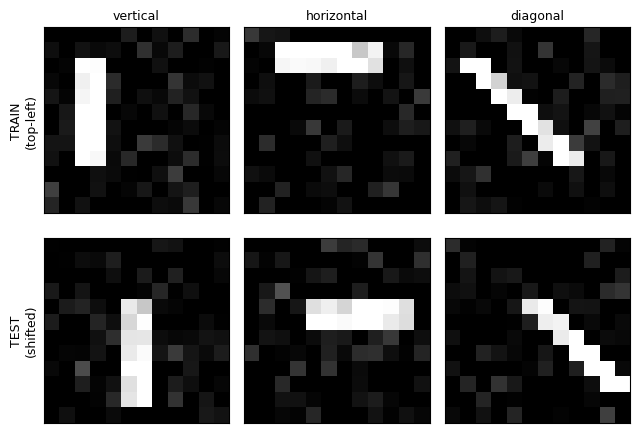


frozen filter bank: 4 filters -> output depth 4


In [14]:
# --- Assessment setup: DO NOT MODIFY ---

X_train, y_train = make_dataset(n_per_class=40, pos_lo=1, pos_hi=2, seed=1)   # top-left
X_test,  y_test  = make_dataset(n_per_class=20, pos_lo=4, pos_hi=5, seed=2)   # shifted

print("train:", X_train.shape, " test:", X_test.shape)

fig, axes = plt.subplots(2, 3, figsize=(6.5, 4.6))
for k in range(3):
    axes[0, k].imshow(X_train[y_train == k][0], cmap="gray", vmin=0, vmax=1)
    axes[1, k].imshow(X_test[y_test == k][0], cmap="gray", vmin=0, vmax=1)
    axes[0, k].set_title(names[k], fontsize=9)
    for r in range(2):
        axes[r, k].set_xticks([]); axes[r, k].set_yticks([])
axes[0, 0].set_ylabel("TRAIN\n(top-left)", fontsize=9)
axes[1, 0].set_ylabel("TEST\n(shifted)", fontsize=9)
plt.tight_layout(); plt.show()

# The frozen filtering layer: both polarities of both directions,
# because ReLU discards negative responses.
FILTER_BANK = [sobel_x, -sobel_x, sobel_y, -sobel_y]
print("\nfrozen filter bank:", len(FILTER_BANK), "filters -> output depth 4")

### Q1 — Blocks 1–3 as a feature extractor

For each image, run **conv → relu → pool → flatten** and collect the results into a matrix.

Divide the final matrix by 4.0. Sobel responses reach about 4, and Lab 2 taught you that large
inputs destabilise gradient descent.


In [15]:
def extract_features(images, pool_size):
    """Blocks 1-3 on every image. Returns (n_images, n_features)."""
    out = []
    for img in images:
        # block 1 (conv with FILTER_BANK), then relu
        t = conv_layer(img, FILTER_BANK)
        t = relu_layer(t)
        # block 2 (max pool with pool_size), then block 3 (flatten)
        t = maxpool_layer(t, pool_size)
        out.append(flatten_layer(t))
    return np.array(out) / 4.0


# --- self-check ---
F = extract_features(X_train, pool_size=5)
assert F.shape == (120, 16), f"(10,10,4) -> pool 5 -> (2,2,4) -> flatten 16, got {F.shape}"
assert F.min() >= 0, "ReLU means nothing is negative"

G = extract_features(X_train, pool_size=10)
assert G.shape == (120, 4), f"global pooling -> (1,1,4) -> flatten 4, got {G.shape}"
print("Q1 passed")

print("\naverage feature vector per class (global pooling):")
for k in range(3):
    print(f"  {names[k]:11s} {G[y_train == k].mean(axis=0)}")

Q1 passed

average feature vector per class (global pooling):
  vertical    [0.974 0.977 0.727 0.737]
  horizontal  [0.718 0.722 0.965 0.978]
  diagonal    [0.754 0.753 0.752 0.75 ]


Look at those four-number signatures. The vertical bar scores high on the first two (the
`sobel_x` pair) and lower on the last two; the horizontal bar reverses it; the diagonal sits
between. Four numbers, three classes, cleanly separated.

### Q2 — Raw pixels versus the CNN pipeline

Train the same block-4 head on two different representations.


In [16]:
def accuracy(head, X, y):
    # forward -> softmax -> argmax -> compare with y
    preds = np.argmax(softmax(head.forward(X)), axis=1)
    return np.mean(preds == y)


# ---------- baseline: no blocks 1-3, just raw pixels ----------
# flatten each image to 144 numbers. Hint: X_train.reshape(len(X_train), -1)
P_train = X_train.reshape(len(X_train), -1)
P_test = X_test.reshape(len(X_test), -1)
head_pixels = train_head(P_train, y_train)

# ---------- the CNN pipeline, global pooling ----------
# features for both sets with pool_size=10
F_train = extract_features(X_train, pool_size=10)
F_test = extract_features(X_test, pool_size=10)
head_conv = train_head(F_train, y_train)

# ---------- compare ----------
print(f"{'model':<26} {'features':>9} {'params':>7} {'train':>7} {'test':>7}")
print("-" * 60)
for lbl, h, tr, te in [("raw pixels (no conv)", head_pixels, P_train, P_test),
                       ("CNN, global pooling", head_conv, F_train, F_test)]:
    print(f"{lbl:<26} {tr.shape[1]:>9} {h.weights.size + h.biases.size:>7} "
          f"{accuracy(h, tr, y_train):>7.3f} {accuracy(h, te, y_test):>7.3f}")

# --- self-check ---
assert accuracy(head_pixels, P_train, y_train) > 0.95, "pixel model should fit TRAINING data"
assert accuracy(head_conv, F_test, y_test) > 0.90, "CNN should generalise to shifted images"
assert accuracy(head_conv, F_test, y_test) > accuracy(head_pixels, P_test, y_test)
print("\nQ2 passed")

model                       features  params   train    test
------------------------------------------------------------
raw pixels (no conv)             144     435   1.000   0.333
CNN, global pooling                4      15   1.000   1.000

Q2 passed


The pixel model scores **100% on training data and exactly chance on the test set**. It did
not learn what a vertical bar looks like — it learned which pixels are bright in *these particular
images*, and that is worthless three pixels to the right.

The CNN pipeline uses **15 parameters** and handles the shifted images perfectly.

### Q3 — How much pooling?

Global pooling throws away all position information. Is that always right? Measure it.


 pool  features  params   train    test
----------------------------------------
    2       100     303   1.000   0.333
    5        16      51   1.000   0.667
   10         4      15   1.000   1.000  <- global


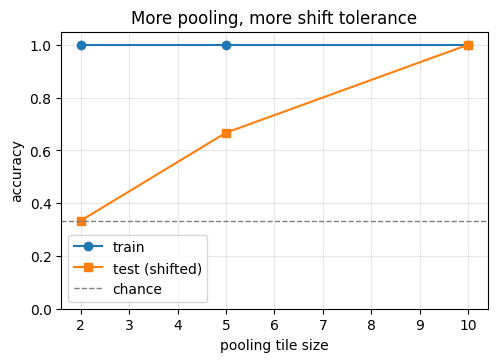

Q3 passed


In [17]:
results = []
for pool in [2, 5, 10]:
    # features for train and test at this pool size, then train a head
    Ftr = extract_features(X_train, pool_size=pool)
    Fte = extract_features(X_test, pool_size=pool)
    h = train_head(Ftr, y_train)
    results.append((pool, Ftr.shape[1], h.weights.size + h.biases.size,
                    accuracy(h, Ftr, y_train), accuracy(h, Fte, y_test)))

print(f"{'pool':>5} {'features':>9} {'params':>7} {'train':>7} {'test':>7}")
print("-" * 40)
for pool, nf, npar, tr, te in results:
    print(f"{pool:>5} {nf:>9} {npar:>7} {tr:>7.3f} {te:>7.3f}"
          f"{'  <- global' if pool == 10 else ''}")

plt.figure(figsize=(5.5, 3.6))
plt.plot([r[0] for r in results], [r[3] for r in results], "o-", label="train")
plt.plot([r[0] for r in results], [r[4] for r in results], "s-", label="test (shifted)")
plt.axhline(1/3, color="grey", ls="--", lw=1, label="chance")
plt.xlabel("pooling tile size"); plt.ylabel("accuracy"); plt.ylim(0, 1.05)
plt.legend(); plt.grid(alpha=0.3); plt.title("More pooling, more shift tolerance")
plt.show()

# --- self-check ---
assert len(results) == 3
assert results[0][4] < results[2][4], "test accuracy should rise with bigger pooling tiles"
print("Q3 passed")

### Q4 — Short answers *(3 marks)*

1. The raw-pixel model scored 1.000 on training data and 0.333 on the test set. What is 0.333 for
   a 3-class problem, and what does the gap tell you?
2. With `pool=2` the model uses convolution and **still** fails on the shifted test set. So which
   block is actually responsible for the translation invariance — and why is convolution alone not
   enough?
3. In this lab, more pooling always improved test accuracy. Describe a task where the **opposite**
   would be true, and say why.


> **Your answers:**
>
> 1. With three equally likely classes, guessing at random gives 1/3 ≈ 0.333 accuracy — this is "chance" performance, i.e. the model is doing no better than a coin flip between three options. The gap between 1.000 (train) and 0.333 (test) shows the model **memorised** the training data rather than learning a general rule: it fit the specific pixel positions of the training images perfectly, but those positions never appear in the shifted test images, so it has learned nothing transferable. This is a textbook case of overfitting driven by the lack of translation invariance in a plain dense layer.
>
> 2. **Max pooling (Block 2)** is what actually produces translation invariance, not convolution alone. Convolution with `pool=2` still preserves a fine-grained spatial grid — the *position* of a strong filter response within that 5x5 grid still matters to the dense layer that follows, so shifting the shape by a few pixels moves which grid cell lights up and confuses the classifier. Only pooling with a large enough tile (especially global pooling) collapses that position information away, leaving just "did this feature fire anywhere," which is what tolerates the shift. Convolution provides the *weight-shared feature detection*; pooling provides the *positional tolerance*.
>
> 3. Any task where the **exact location** of a feature is part of the label needs the opposite: e.g. face landmark detection (finding the precise (x, y) of eyes/nose/mouth), object detection/localisation (drawing a bounding box), or segmentation (labelling every pixel). If you pool too aggressively there, you throw away the very spatial information the task needs to output, so accuracy would fall as pooling tile size grows rather than rise.

---

## What you built today

All four blocks of a CNN, from scratch, and a demonstration that they work: **15 parameters
classified shifted images perfectly, while 435 parameters scored exactly chance.**

| Block | You wrote | Learnable |
|---|---|---|
| 1 · Filtering | `convolve2d`, `conv_layer`, `relu_layer` | yes |
| 2 · Max pooling | `max_pool2d`, `maxpool_layer` | no |
| 3 · Flatten | `flatten_layer` | no |
| 4 · Fully connected | `Layer_Dense` (from Lab 2) | yes |

The ideas underneath: **weight sharing** (one filter, used everywhere), **sparse connectivity**
(each output sees a small patch), **pooling** (trading spatial precision for shift tolerance), and
**frozen base + trained head** (transfer learning).

### What was simplified

* **Our filters were hand-designed.** Real CNNs learn them — and as CNN Explainer showed, they
  learn filters much like Sobel anyway. Backpropagation through a convolutional layer must sum the
  gradient over every position a shared weight was used.
* **One conv layer.** Real networks stack blocks so later layers combine simple features into
  complex ones.
* **No real pretrained weights.** Labs 7–8 do genuine transfer learning with a network trained on
  millions of images.
* **Tiny 12×12 greyscale images.** The principles are identical at 224×224 RGB; only runtime
  changes.


### Before next week

* Restart the kernel and run everything top to bottom. Every assertion should pass.
* Keep this notebook — all four block functions come back.
* Revisit **CNN Explainer** now that you have built the pieces. It reads completely differently
  the second time.

---

### Submission

1. Create a new repository on GitHub for this course and name it `arti402`.
2. Rename this file to `arti402_Lab3_<YourID>.ipynb` and upload the completed notebook, with all
   outputs visible, to your repository.
